# 82 - YOLO-World オープン語彙検出

## 概要
ultralytics 内蔵の YOLO-World を用いて、テキストプロンプトによるオープン語彙物体検出を実験する。
YOLO11 (NB81) の固定80クラスでは検出できなかった物体が、自由なテキスト指定で検出できるかを検証する。

## 手法
- モデル: YOLO-World (ultralytics 統合版)
- カテゴリ固有のプロンプトセットを設計
- YOLO11 との比較: 同一画像での検出結果の差分を分析

## 入力
- `data/images.duckdb` (image_catalog, object_detections テーブル)

## 出力
- `data/images.duckdb` (object_detections に YOLO-World 結果追加)
- `data/82_yolo_world_samples.png`
- `data/82_yolo11_vs_yoloworld.png`

In [1]:
import time
import uuid
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.notebook import tqdm
from ultralytics import YOLO

## 1. 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")

# YOLO-World 設定
MODEL_VARIANT = "yolov8s-worldv2.pt"  # YOLO-World v2 Small
MODEL_NAME = "yolo-world-v2-s"  # DB保存用
IMGSZ = 1280
CONF_THRESHOLD = 0.1  # open-vocab は信頼度が低めなので閾値を下げる

COMMIT_INTERVAL = 50

# カテゴリ固有のプロンプトセット
CATEGORY_PROMPTS = {
    "KashiwaVillagePark2026": [
        "duck", "mallard", "water bird", "pond", "bench", "tree",
        "grass", "person", "bridge", "playground"
    ],
    "TokyoNight202505": [
        "tower", "skytree", "neon sign", "street light", "building",
        "car", "person", "illumination", "river", "bridge"
    ],
    "EuroPython2025": [
        "person", "microphone", "projector screen", "laptop", "lanyard",
        "badge", "speaker", "audience", "chair", "table"
    ],
    "PyConJP2025": [
        "person", "microphone", "projector screen", "laptop", "lanyard",
        "badge", "speaker", "audience", "chair", "table"
    ],
    "PyConJP2025-PreCampHiroshima": [
        "person", "laptop", "whiteboard", "projector screen", "chair",
        "table", "building", "city"
    ],
    "terada": [
        "person", "microphone", "lanyard", "badge", "podium",
        "projector screen"
    ],
}

# 共通プロンプト（カテゴリ非依存）
COMMON_PROMPTS = [
    "person", "bird", "duck", "laptop", "chair", "table",
    "microphone", "screen", "car", "tree", "building", "tower",
    "bench", "lanyard", "badge"
]

print(f"カテゴリ固有プロンプト: {len(CATEGORY_PROMPTS)} カテゴリ")
print(f"共通プロンプト: {len(COMMON_PROMPTS)} クラス")

カテゴリ固有プロンプト: 6 カテゴリ
共通プロンプト: 15 クラス


## 2. モデルの読み込み

In [3]:
print("YOLO-World モデルを読み込み中...")
model = YOLO(MODEL_VARIANT)
print(f"モデル: {MODEL_VARIANT}")
print(f"入力解像度: {IMGSZ}")
print(f"信頼度閾値: {CONF_THRESHOLD}")

YOLO-World モデルを読み込み中...
モデル: yolov8s-worldv2.pt
入力解像度: 1280
信頼度閾値: 0.1


## 3. 共通プロンプトでの検出（全378枚）

In [4]:
conn = duckdb.connect(str(DB_PATH))

# 既存レコード削除（再実行対応）
existing = conn.execute("""
    SELECT COUNT(*) FROM object_detections WHERE model_name = ?
""", [MODEL_NAME]).fetchone()[0]
if existing > 0:
    print(f"既存レコード {existing} 件を削除します")
    conn.execute("DELETE FROM object_detections WHERE model_name = ?", [MODEL_NAME])
    conn.commit()

# 全画像を取得
all_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    ORDER BY category, file_name
""").fetchdf()

print(f"処理対象: {len(all_images)} 画像")

既存レコード 8923 件を削除します
処理対象: 378 画像


In [5]:
# 共通プロンプトで検出クラスを設定
model.set_classes(COMMON_PROMPTS)
prompt_text = ", ".join(COMMON_PROMPTS)
print(f"検出プロンプト: {prompt_text}")

total_detections = 0
total_images = 0
errors = []
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(all_images.iterrows(), total=len(all_images), desc="YOLO-World 検出")):
    try:
        results = model(row["file_path"], imgsz=IMGSZ, conf=CONF_THRESHOLD, verbose=False)
        total_images += 1

        for r in results:
            for box in r.boxes:
                detection_id = str(uuid.uuid4())
                cls_idx = int(box.cls)
                label = COMMON_PROMPTS[cls_idx] if cls_idx < len(COMMON_PROMPTS) else f"class_{cls_idx}"
                confidence = float(box.conf)
                x1, y1, x2, y2 = [float(v) for v in box.xyxy[0]]

                conn.execute("""
                    INSERT INTO object_detections
                    (detection_id, image_id, model_name, label, confidence,
                     bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                """, [
                    detection_id, row["id"], MODEL_NAME,
                    label, confidence,
                    x1, y1, x2, y2, prompt_text
                ])
                total_detections += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

conn.commit()

elapsed = time.time() - start_time
print(f"\n処理完了:")
print(f"  処理画像数: {total_images}")
print(f"  総検出数: {total_detections}")
print(f"  平均検出数/画像: {total_detections / max(total_images, 1):.1f}")
print(f"  処理時間: {elapsed:.1f} 秒 ({total_images / max(elapsed, 0.01):.1f} img/s)")
print(f"  エラー数: {len(errors)}")

検出プロンプト: person, bird, duck, laptop, chair, table, microphone, screen, car, tree, building, tower, bench, lanyard, badge


YOLO-World 検出:   0%|          | 0/378 [00:00<?, ?it/s]


処理完了:
  処理画像数: 378
  総検出数: 8923
  平均検出数/画像: 23.6
  処理時間: 75.9 秒 (5.0 img/s)
  エラー数: 0


## 4. カテゴリ固有プロンプトでの追加検出

共通プロンプトに含まれないカテゴリ特有の語彙で追加検出を行い、
別の `model_name` で保存する。

In [6]:
import torch

CATEGORY_MODEL_NAME = "yolo-world-v2-s-category"  # カテゴリ特化版

# set_classes 2回目呼び出しのデバイス不一致を回避するためモデルをリロード
del model
torch.cuda.empty_cache()
model = YOLO(MODEL_VARIANT)

# 既存の category 版を削除
conn.execute("DELETE FROM object_detections WHERE model_name = ?", [CATEGORY_MODEL_NAME])
conn.commit()

total_cat_detections = 0
start_time = time.time()

for category, prompts in CATEGORY_PROMPTS.items():
    cat_images = all_images[all_images["category"] == category]
    print(f"\n--- {category} ({len(cat_images)} 枚) ---")
    print(f"    プロンプト: {prompts}")

    model.set_classes(prompts)
    cat_prompt_text = ", ".join(prompts)

    for _, row in tqdm(cat_images.iterrows(), total=len(cat_images), desc=category[:20]):
        try:
            results = model(row["file_path"], imgsz=IMGSZ, conf=CONF_THRESHOLD, verbose=False)
            for r in results:
                for box in r.boxes:
                    detection_id = str(uuid.uuid4())
                    cls_idx = int(box.cls)
                    label = prompts[cls_idx] if cls_idx < len(prompts) else f"class_{cls_idx}"
                    confidence = float(box.conf)
                    x1, y1, x2, y2 = [float(v) for v in box.xyxy[0]]

                    conn.execute("""
                        INSERT INTO object_detections
                        (detection_id, image_id, model_name, label, confidence,
                         bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                    """, [
                        detection_id, row["id"], CATEGORY_MODEL_NAME,
                        label, confidence,
                        x1, y1, x2, y2, cat_prompt_text
                    ])
                    total_cat_detections += 1
        except Exception as e:
            print(f"  Error: {row['id']}: {e}")

    conn.commit()

    # カテゴリ切り替え時のデバイス不一致を回避
    del model
    torch.cuda.empty_cache()
    model = YOLO(MODEL_VARIANT)

elapsed = time.time() - start_time
print(f"\nカテゴリ固有検出完了:")
print(f"  総検出数: {total_cat_detections}")
print(f"  処理時間: {elapsed:.1f} 秒")


--- KashiwaVillagePark2026 (56 枚) ---
    プロンプト: ['duck', 'mallard', 'water bird', 'pond', 'bench', 'tree', 'grass', 'person', 'bridge', 'playground']


KashiwaVillagePark20:   0%|          | 0/56 [00:00<?, ?it/s]


--- TokyoNight202505 (49 枚) ---
    プロンプト: ['tower', 'skytree', 'neon sign', 'street light', 'building', 'car', 'person', 'illumination', 'river', 'bridge']


TokyoNight202505:   0%|          | 0/49 [00:00<?, ?it/s]


--- EuroPython2025 (129 枚) ---
    プロンプト: ['person', 'microphone', 'projector screen', 'laptop', 'lanyard', 'badge', 'speaker', 'audience', 'chair', 'table']


...


--- PyConJP2025-PreCampHiroshima (57 枚) ---
    プロンプト: ['person', 'laptop', 'whiteboard', 'projector screen', 'chair', 'table', 'building', 'city']


PyConJP2025-PreCampH:   0%|          | 0/57 [00:00<?, ?it/s]


--- terada (10 枚) ---
    プロンプト: ['person', 'microphone', 'lanyard', 'badge', 'podium', 'projector screen']


terada:   0%|          | 0/10 [00:00<?, ?it/s]


カテゴリ固有検出完了:
  総検出数: 8550
  処理時間: 77.8 秒


## 5. YOLO11 vs YOLO-World 比較分析

In [7]:
# YOLO11 と YOLO-World の検出統計比較
comparison = conn.execute("""
    SELECT
        d.model_name,
        COUNT(*) as total_detections,
        COUNT(DISTINCT d.image_id) as images_with_dets,
        COUNT(DISTINCT d.label) as unique_classes,
        ROUND(AVG(d.confidence), 3) as avg_confidence,
        ROUND(MEDIAN(d.confidence), 3) as median_confidence
    FROM object_detections d
    WHERE d.model_name IN ('yolo11s', ?)
    GROUP BY d.model_name
    ORDER BY d.model_name
""", [MODEL_NAME]).fetchdf()

print("YOLO11 vs YOLO-World 比較:")
display(comparison)

YOLO11 vs YOLO-World 比較:


,model_name,total_detections,images_with_dets,unique_classes,avg_confidence,median_confidence
0,yolo-world-v2-s,8923,370,13,0.320,0.222
1,yolo11s,5000,344,53,0.561,0.535


In [8]:
# カテゴリ別比較
cat_comparison = conn.execute("""
    SELECT
        c.category,
        d.model_name,
        COUNT(*) as detection_count,
        COUNT(DISTINCT d.label) as unique_classes
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name IN ('yolo11s', ?)
    GROUP BY c.category, d.model_name
    ORDER BY c.category, d.model_name
""", [MODEL_NAME]).fetchdf()

print("カテゴリ別 検出数比較:")
display(cat_comparison.pivot_table(
    index="category", columns="model_name",
    values="detection_count", fill_value=0
))

カテゴリ別 検出数比較:


model_name,yolo-world-v2-s,yolo11s
category,,
EuroPython2025,3813.0,1928.0
KashiwaVillagePark2026,353.0,234.0
PyConJP2025,2619.0,1788.0
PyConJP2025-PreCampHiroshima,1685.0,808.0
TokyoNight202505,418.0,228.0
terada,35.0,14.0


In [9]:
# YOLO-World で検出されたが YOLO11 では検出されなかったクラス
yolo11_classes = set(conn.execute("""
    SELECT DISTINCT label FROM object_detections WHERE model_name = 'yolo11s'
""").fetchdf()["label"])

yoloworld_classes = set(conn.execute("""
    SELECT DISTINCT label FROM object_detections WHERE model_name = ?
""", [MODEL_NAME]).fetchdf()["label"])

yoloworld_cat_classes = set(conn.execute("""
    SELECT DISTINCT label FROM object_detections WHERE model_name = ?
""", [CATEGORY_MODEL_NAME]).fetchdf()["label"])

new_classes_common = yoloworld_classes - yolo11_classes
new_classes_category = yoloworld_cat_classes - yolo11_classes

print(f"YOLO11 ユニーククラス: {len(yolo11_classes)}")
print(f"YOLO-World (共通) ユニーククラス: {len(yoloworld_classes)}")
print(f"YOLO-World (カテゴリ特化) ユニーククラス: {len(yoloworld_cat_classes)}")
print(f"\nYOLO-World のみで検出されたクラス (共通): {sorted(new_classes_common)}")
print(f"YOLO-World のみで検出されたクラス (カテゴリ特化): {sorted(new_classes_category)}")

YOLO11 ユニーククラス: 53
YOLO-World (共通) ユニーククラス: 13
YOLO-World (カテゴリ特化) ユニーククラス: 18

YOLO-World のみで検出されたクラス (共通): ['building', 'duck', 'microphone', 'screen', 'table', 'tower', 'tree']
YOLO-World のみで検出されたクラス (カテゴリ特化): ['audience', 'building', 'duck', 'microphone', 'projector screen', 'river', 'speaker', 'street light', 'table', 'tower', 'tree', 'water bird', 'whiteboard']


## 6. サンプル可視化

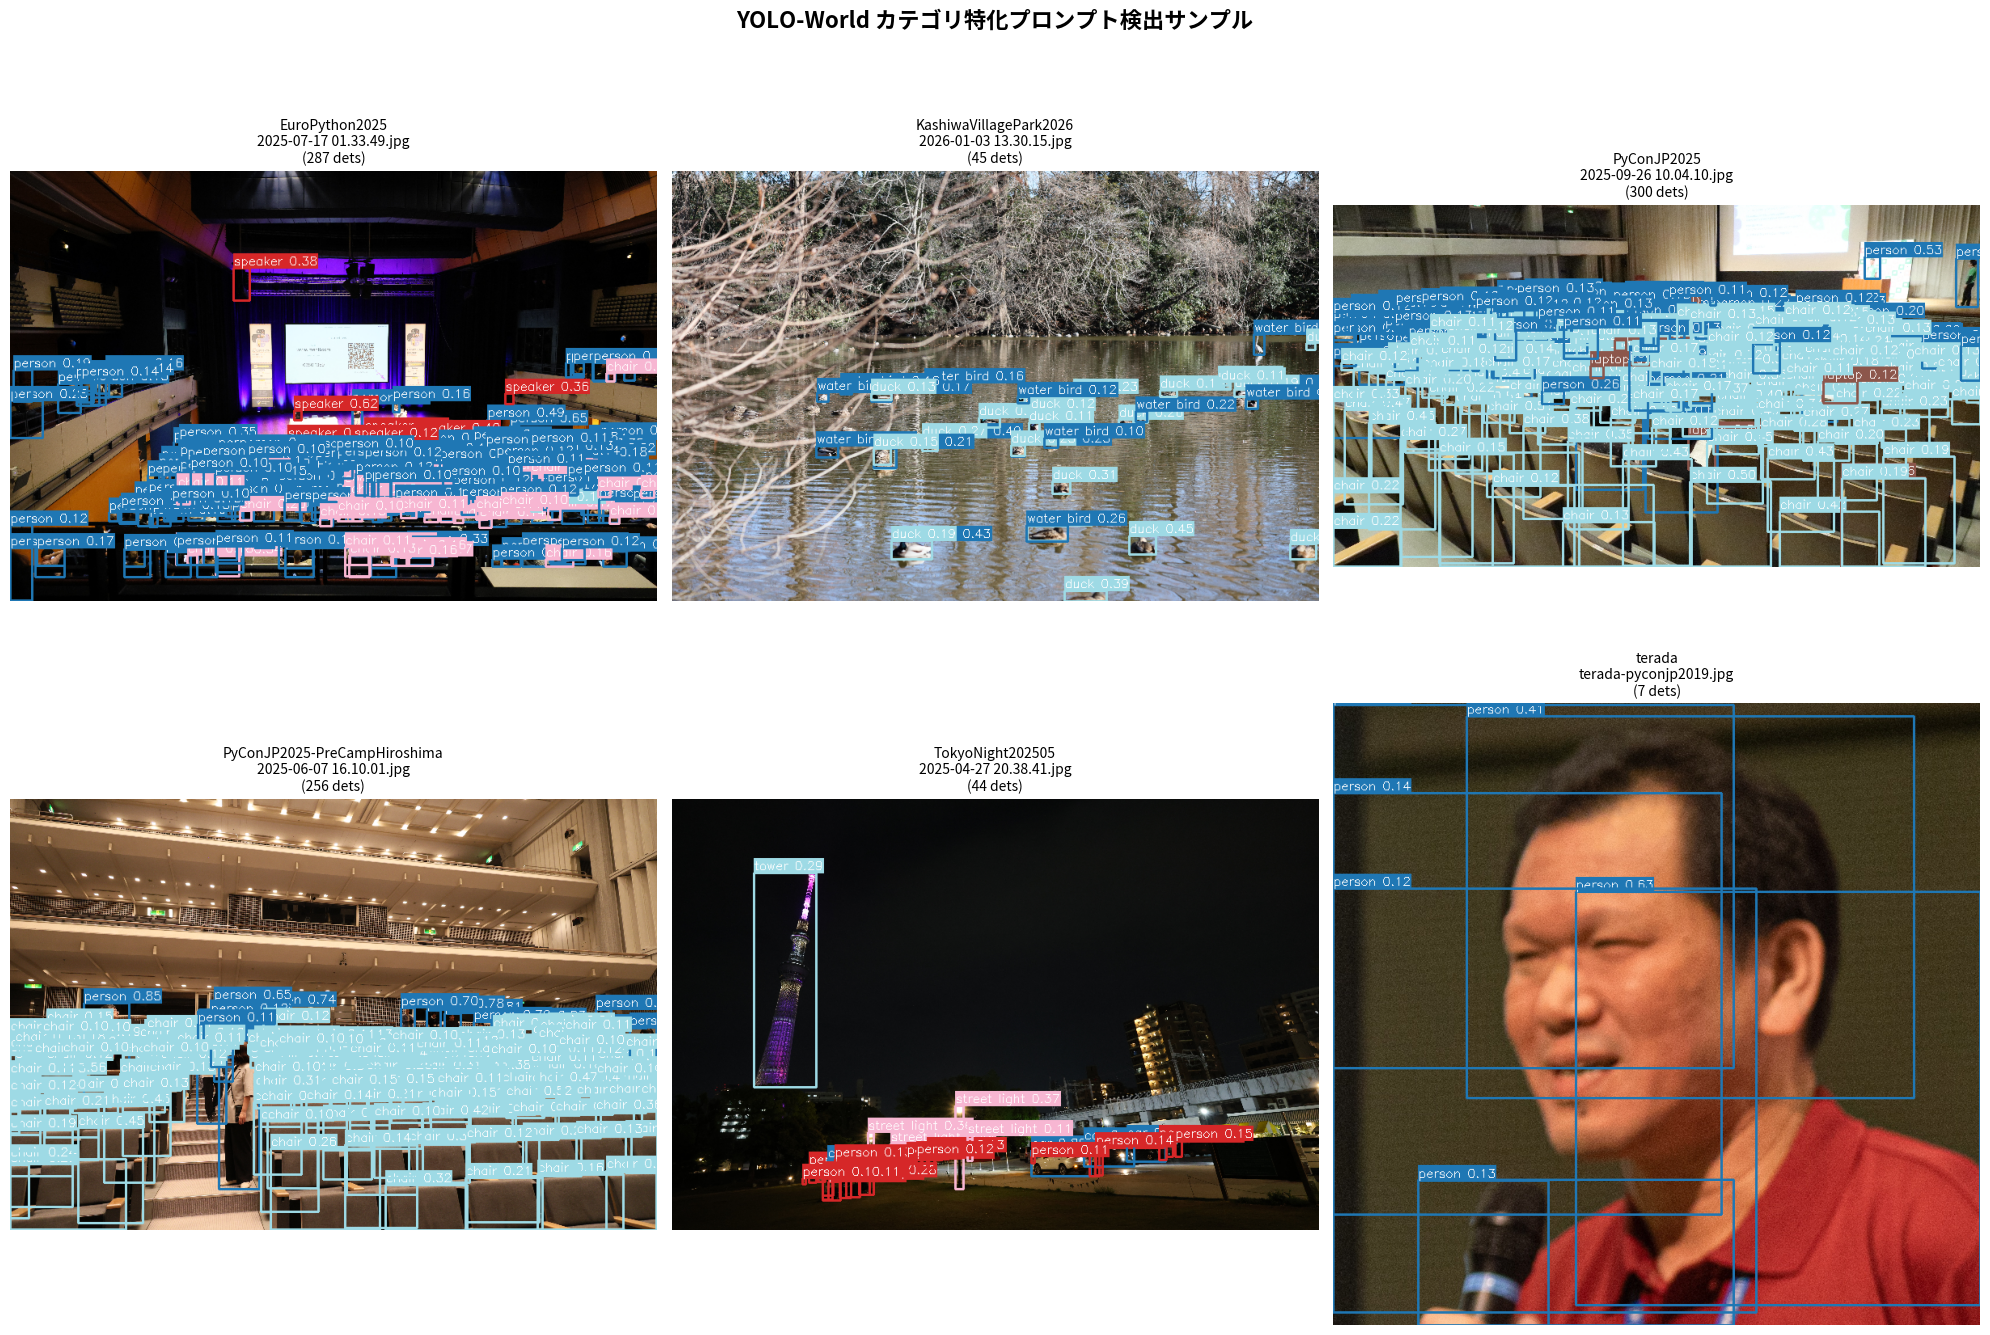

Saved: data/82_yolo_world_samples.png


In [10]:
def draw_detections(image_path, detections_df, max_width=800):
    """画像にバウンディングボックスとラベルを描画する。"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if w > max_width:
        scale = max_width / w
        img = cv2.resize(img, (max_width, int(h * scale)))
    else:
        scale = 1.0

    unique_labels = detections_df["label"].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 1)))
    label_colors = {label: colors[i] for i, label in enumerate(unique_labels)}

    for _, det in detections_df.iterrows():
        x1, y1 = int(det["bbox_x1"] * scale), int(det["bbox_y1"] * scale)
        x2, y2 = int(det["bbox_x2"] * scale), int(det["bbox_y2"] * scale)
        color = tuple(int(c * 255) for c in label_colors[det["label"]][:3])
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label_text = f"{det['label']} {det['confidence']:.2f}"
        (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw, y1), color, -1)
        cv2.putText(img, label_text, (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    return img


# 各カテゴリからサンプル1枚ずつ、YOLO-World (カテゴリ特化) の検出結果を可視化
sample_images = conn.execute("""
    WITH ranked AS (
        SELECT
            c.id, c.file_path, c.file_name, c.category,
            COUNT(d.detection_id) as det_count,
            ROW_NUMBER() OVER (PARTITION BY c.category ORDER BY COUNT(d.detection_id) DESC) as rn
        FROM image_catalog c
        JOIN object_detections d ON c.id = d.image_id AND d.model_name = ?
        GROUP BY c.id, c.file_path, c.file_name, c.category
    )
    SELECT id, file_path, file_name, category, det_count
    FROM ranked WHERE rn = 1
    ORDER BY category
""", [CATEGORY_MODEL_NAME]).fetchdf()

n_samples = len(sample_images)
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_images.iterrows()):
    if i >= 6:
        break
    dets = conn.execute("""
        SELECT label, confidence, bbox_x1, bbox_y1, bbox_x2, bbox_y2
        FROM object_detections
        WHERE image_id = ? AND model_name = ?
        ORDER BY confidence DESC
    """, [row["id"], CATEGORY_MODEL_NAME]).fetchdf()

    img = draw_detections(row["file_path"], dets)
    axes[i].imshow(img)
    axes[i].set_title(f"{row['category']}\n{row['file_name'][:30]}\n({len(dets)} dets)", fontsize=10)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("YOLO-World カテゴリ特化プロンプト検出サンプル", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/82_yolo_world_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/82_yolo_world_samples.png")

## 7. YOLO11 vs YOLO-World 可視化

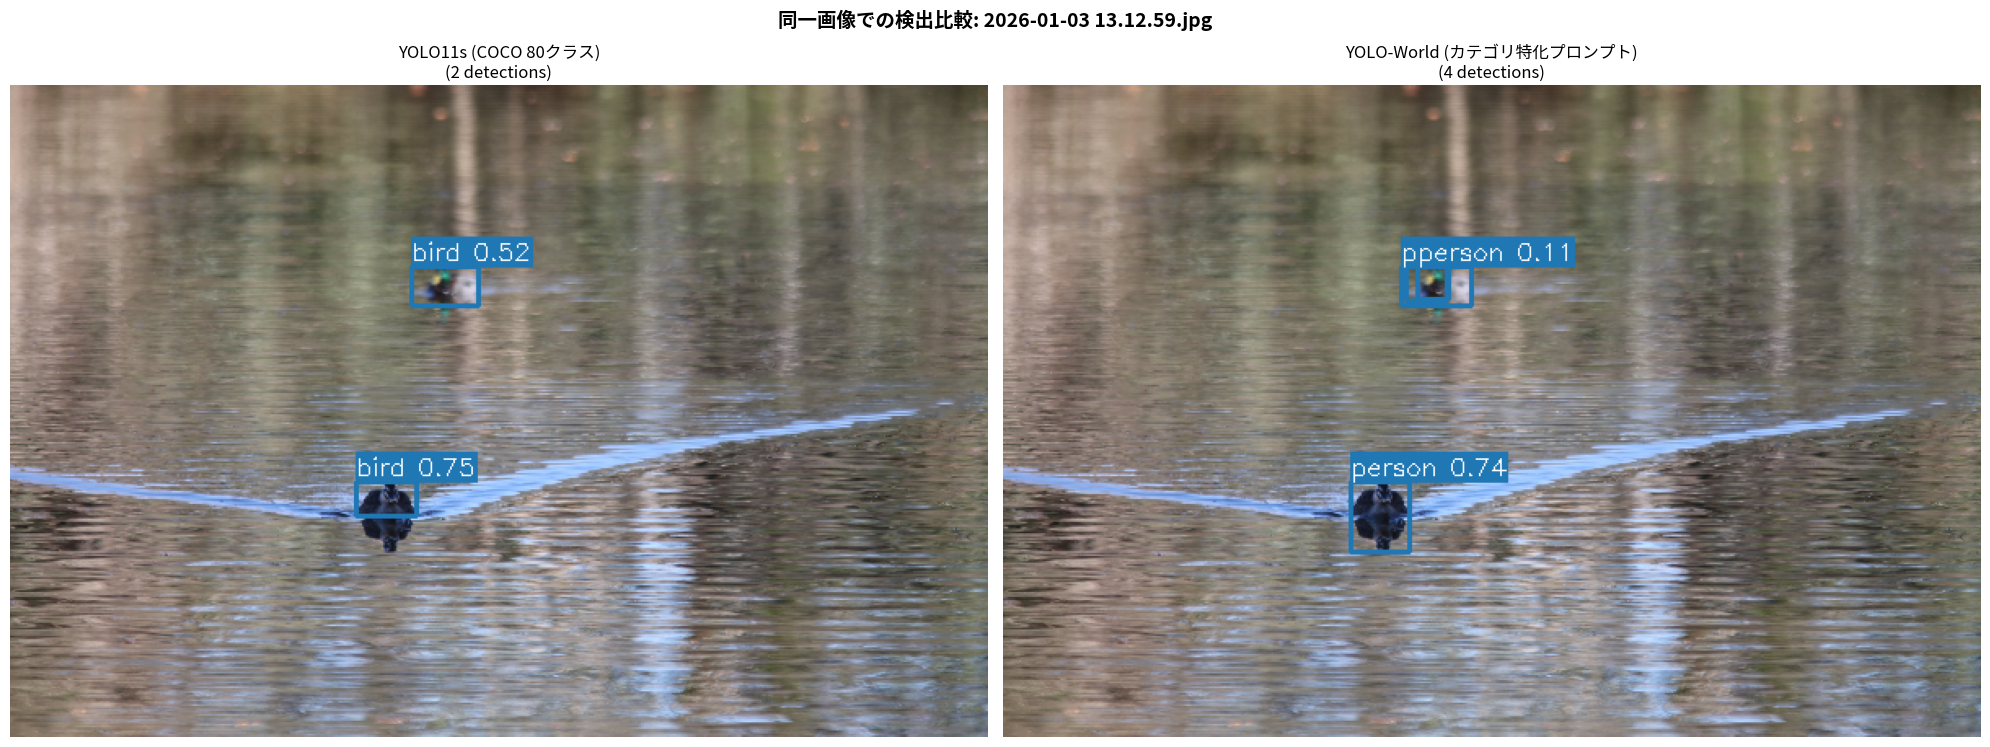

Saved: data/82_yolo11_vs_yoloworld.png


In [11]:
# 同一画像で YOLO11 vs YOLO-World を並べて比較
# KashiwaVillagePark からサンプル1枚を選択（duck 検出の期待値が高い）
sample_id = conn.execute("""
    SELECT c.id, c.file_path, c.file_name
    FROM image_catalog c
    WHERE c.category = 'KashiwaVillagePark2026'
    ORDER BY c.file_name
    LIMIT 1
""").fetchone()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (m_name, title) in zip(axes, [
    ("yolo11s", "YOLO11s (COCO 80クラス)"),
    (CATEGORY_MODEL_NAME, "YOLO-World (カテゴリ特化プロンプト)"),
]):
    dets = conn.execute("""
        SELECT label, confidence, bbox_x1, bbox_y1, bbox_x2, bbox_y2
        FROM object_detections
        WHERE image_id = ? AND model_name = ?
        ORDER BY confidence DESC
    """, [sample_id[0], m_name]).fetchdf()

    img = draw_detections(sample_id[1], dets, max_width=600)
    ax.imshow(img)
    ax.set_title(f"{title}\n({len(dets)} detections)", fontsize=12)
    ax.axis("off")

plt.suptitle(f"同一画像での検出比較: {sample_id[2]}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/82_yolo11_vs_yoloworld.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/82_yolo11_vs_yoloworld.png")

## まとめ・評価・考察

### 実験結果

| 項目 | YOLO-World (共通) | YOLO-World (カテゴリ特化) | YOLO11s |
|:-----|:---:|:---:|:---:|
| 総検出数 | 8,923 | 8,550 | 5,000 |
| ユニーククラス | 13 | 18 | 53 |
| 検出あり画像数 | 370 (97.9%) | 362 (95.8%) | 344 (91.0%) |
| 平均信頼度 | 0.320 | 0.327 | 0.561 |
| 処理速度 | 5.0 img/s | — | 5.0 img/s |

### 評価

- **検出数の大幅増加**: YOLO-World は YOLO11 比で **78.6% 増** (8,923 vs 5,000)。open-vocab の柔軟なプロンプトにより、同一画像からより多くの物体を拾い上げる。
- **新規クラスの検出成功**: YOLO11 では検出不可能だった `duck`, `microphone`, `tower`, `building`, `tree`, `screen`, `table` を検出。カテゴリ特化版ではさらに `projector screen`, `water bird`, `whiteboard`, `speaker`, `audience` 等を追加。
- **信頼度の低さ**: 平均信頼度 0.320 は YOLO11 (0.561) と比較して大幅に低い。open-vocab モデルは「何でも検出しようとする」ため、閾値を下げると誤検出が増える傾向がある。
- **カバレッジの向上**: 97.9% (370/378) で YOLO11 の 91.0% を上回り、ほぼ全画像で検出が得られた。

### 考察

- **open-vocab の価値**: COCO 80クラスに含まれない語彙 (`duck`, `lanyard`, `projector screen` 等) を柔軟に指定できるのが最大の利点。ドメイン固有の検出タスクに適している。
- **プロンプト設計の重要性**: カテゴリ特化プロンプトでは 18 クラス vs 共通プロンプトの 13 クラスとラベル多様性が向上。適切なプロンプト設計が検出品質を左右する。
- **YOLO-World の制約**: `set_classes()` を2回目以降に呼ぶと CUDA/CPU デバイス不一致エラーが発生。モデルのリロードで回避したが、ultralytics の既知バグの可能性がある。
- **YOLO11 との使い分け**: YOLO11 は「何があるか網羅的に調べる」用途、YOLO-World は「特定の物体を探す」用途に適している。

In [12]:
# 最終統計
model_stats = conn.execute("""
    SELECT
        model_name,
        COUNT(*) as total_dets,
        COUNT(DISTINCT label) as unique_classes,
        COUNT(DISTINCT image_id) as images_with_dets,
        ROUND(AVG(confidence), 3) as avg_conf
    FROM object_detections
    GROUP BY model_name
    ORDER BY model_name
""").fetchdf()

print("=" * 60)
print("全モデル検出統計")
print("=" * 60)
display(model_stats)

全モデル検出統計


,model_name,total_dets,unique_classes,images_with_dets,avg_conf
0,yolo-world-v2-s,8923,13,370,0.320
1,yolo-world-v2-s-category,8550,18,362,0.327
2,yolo11s,5000,53,344,0.561


In [13]:
conn.close()
print(f"完了: {DB_PATH.resolve()}")

完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb
